# 1. Problem Definition
El objetivo de este proyecto es predecir la calidad del vino basándose en sus propiedades químicas. 
- **Target Regresión:** `quality` (puntaje numérico del 0 al 10).
- **Target Clasificación:** `is_good` (binario: 1 si quality >= 7, 0 si no).
Se justifica el uso de regresión lineal para entender la relación continua de los químicos, y la regresión logística para una decisión binaria de control de calidad.

/tmp/ipykernel_3417/603097682.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, ax=axes[0], palette='viridis')
/tmp/ipykernel_3417/603097682.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, ax=axes[1], palette='viridis')


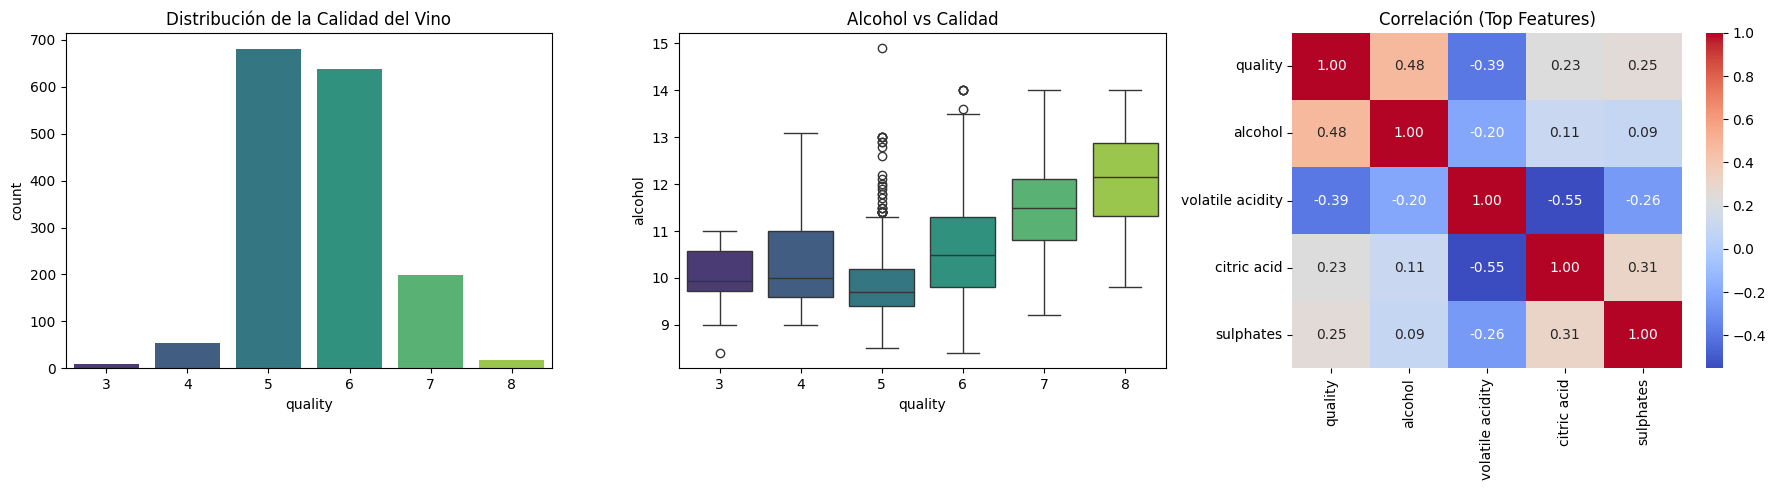

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Descargar el dataset oficial de Wine Quality (Red)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Crear la variable binaria para la regresión logística
df['is_good'] = (df['quality'] >= 7).astype(int)

# --- EDA ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución del target
sns.countplot(x='quality', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de la Calidad del Vino')

# 2. Distribución de un feature clave vs target
sns.boxplot(x='quality', y='alcohol', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Alcohol vs Calidad')

# 3. Heatmap de correlación
sns.heatmap(df[['quality', 'alcohol', 'volatile acidity', 'citric acid', 'sulphates']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=axes[2])
axes[2].set_title('Correlación (Top Features)')

plt.tight_layout()
plt.show()

**Comentarios del EDA:**
1. **Target:** La distribución está fuertemente desbalanceada, con la mayoría de los vinos concentrados en calidades medias (5 y 6).
2. **Features:** Se observa una tendencia clara donde los vinos con mayor nivel de alcohol reciben mejores puntajes de calidad.
3. **Correlación:** El alcohol tiene la correlación positiva más fuerte con la calidad, mientras que la acidez volátil tiene una correlación negativa.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Separar features y targets
X = df.drop(['quality', 'is_good'], axis=1)
y_reg = df['quality']
y_clf = df['is_good']

# Train/Test Split (80/20, semilla fija)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Crear el Pipeline de preprocesamiento (Solo escalado, no hay categóricas)
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Ajustar el pipeline a los datos de entrenamiento
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

print("Datos listos y escalados. El pipeline está preparado para los modelos.")

Datos listos y escalados. El pipeline está preparado para los modelos.
